# Lecture 5 - Exploratory Data Analysis (EDA)
## Practical Lab - Student Notebook
Department of Cybersecurity and Digital Forensics

**Our data:** a small class of 20 students (`data/students.csv`). It is small on purpose, so you can check every answer with your own eyes. It has a few problems hidden inside - you will find them!

**How to use:** run the Setup cell first, then run each exercise in order (`Shift + Enter`). Under each exercise there is a **Try it yourself** task with an empty cell for your answer.

In [65]:
# SETUP - run this cell first (Shift + Enter)
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import pandas as pd  #
import seaborn as sns
%matplotlib inline
warnings.filterwarnings("ignore")

DATA = Path("data")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
TEAL, GOLD, NAVY = "#2D6064", "#C9A96E", "#0F243E"
sns.set_theme(style="whitegrid", palette=[TEAL, GOLD, NAVY, "#7FA7A3"])
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlesize": 13})
pd.set_option("display.width", 120)

def save(fig, name):
    """Save the figure to outputs/ and show it."""
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def load_students():
    return pd.read_csv("students.csv")

def clean_students():
    """The class list after the cleaning steps of Exercises 5 and 6."""
    df = load_students().drop_duplicates()
    df["study_hours"] = df["study_hours"].fillna(df["study_hours"].median())
    df["city"] = df["city"].fillna(df["city"].mode()[0])
    return df.reset_index(drop=True)

def load_sales():
    return pd.read_csv("coffee_sales.csv")

def load_reviews():
    return pd.read_csv("reviews.csv")

STOP_WORDS = {"the", "and", "is", "to", "a", "it", "i", "my", "after",
              "every", "very", "of", "new", "time"}
print("Ready! Students:", load_students().shape)

Ready! Students: (21, 10)


---
# Part A - First look

## Exercise 1
Load the data and look at its size, first rows and column types.

In [66]:
df = load_students()
print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn types:")
print(df.dtypes)

Shape (rows, columns): (21, 10)

First 5 rows:
   student_id    name gender  age    city  study_hours  sleep_hours  attendance  exam_score grade
0           1   Ahmed      M   19  Riyadh         10.0            7          95          88     A
1           2    Sara      F   20  Jeddah          8.0            8          90          82     B
2           3    Omar      M   22  Riyadh          3.0            6          70          51     C
3           4  Fatima      F   18  Dammam         12.0            7          98          94     A
4           5  Khalid      M   23  Jeddah          5.0            5          75          60     C

Column types:
student_id       int64
name               str
gender             str
age              int64
city               str
study_hours    float64
sleep_hours      int64
attendance       int64
exam_score       int64
grade              str
dtype: object


**Try it yourself 1:** How many students scored more than 80?

In [67]:
# Your answer here
high_scorers_count = (df['exam_score'] > 80).sum()
print("Number of students with scores > 80:", high_scorers_count)

high_scorers_df = df[df['exam_score'] > 80]
print("Number of students:", len(high_scorers_df))

print(df[df['exam_score'] > 80][['name', 'exam_score']])

Number of students with scores > 80: 6
Number of students: 6
      name  exam_score
0    Ahmed          88
1     Sara          82
3   Fatima          94
9     Reem          85
14     Ali          86
18   Tariq          90


---
# Part B - Numbers that describe one column

## Exercise 2
Centre (mean, median, mode) and spread (range, std) of a column.

In [68]:
df = clean_students()
x = df["exam_score"]
print("Mean   :", round(x.mean(), 1))
print("Median :", x.median())
print("Range  :", x.max() - x.min(), f"({x.min()} to {x.max()})")
print("Std    :", round(x.std(), 1))
print("Mode of age:", df["age"].mode()[0])
print("\nSkewness of exam_score:", round(x.skew(), 2))
print("Skewness of age       :", round(df["age"].skew(), 2))
print("\nAll at once with describe():")
print(df[["age", "study_hours", "exam_score"]].describe().round(1))

Mean   : 68.8
Median : 66.5
Range  : 52 (42 to 94)
Std    : 16.2
Mode of age: 20

Skewness of exam_score: -0.03
Skewness of age       : 3.86

All at once with describe():
        age  study_hours  exam_score
count  20.0         20.0        20.0
mean   21.8          6.2        68.8
std     5.7          3.0        16.2
min    18.0          2.0        42.0
25%    19.8          4.0        56.5
50%    20.5          5.5        66.5
75%    22.0          8.2        82.8
max    45.0         12.0        94.0


**Try it yourself 2:** Mean, median and std of sleep_hours. Which is bigger: mean or median?

In [69]:
# Your answer here

sleep_mean = df["sleep_hours"].mean()
sleep_median = df["sleep_hours"].median()
sleep_std = df["sleep_hours"].std()

print("Mean   :", round(sleep_mean, 1))
print("Median :", round(sleep_median, 1))
print("Std    :", round(sleep_std, 1))

if sleep_mean > sleep_median:
    print("The Mean is bigger than the Median.")
elif sleep_median > sleep_mean:
    print("The Median is bigger than the Mean.")
else:
    print("Mean and Median are equal.")

Mean   : 6.6
Median : 7.0
Std    : 1.1
The Median is bigger than the Mean.


## Exercise 3
Count how often each category appears.

In [70]:
df = load_students().drop_duplicates()
counts = df["city"].value_counts()
percent = (counts / counts.sum() * 100).round(1)
table = pd.DataFrame({"count": counts, "percent": percent})
print(table)
print("\nMost common city (mode):", counts.idxmax())
print("Students with no city   :", df["city"].isnull().sum())

        count  percent
city                  
Riyadh      9     47.4
Jeddah      6     31.6
Dammam      4     21.1

Most common city (mode): Riyadh
Students with no city   : 1


**Try it yourself 3:** Build a frequency table for 'grade'.

In [71]:
# Your answer here
# Load student data and remove duplicate rows
df = load_students().drop_duplicates()

# Count how many students got each grade
counts = df["grade"].value_counts()

# Percentage of each grade (rounded to 1 decimal)
percent = (counts / counts.sum() * 100).round(1)

# Put count and percent side by side in one table
table = pd.DataFrame({"count": counts, "percent": percent})
print(table)

# Most frequent grade (the mode)
print("\nMost common grade (mode):", counts.idxmax())

# Number of students with a missing grade
print("Students with no grade   :", df["grade"].isnull().sum())

       count  percent
grade                
C          8     40.0
A          5     25.0
B          5     25.0
F          2     10.0

Most common grade (mode): C
Students with no grade   : 0


---
# Part C - Data cleaning

## Exercise 4
Count the missing values and see where they are.

Missing values per column:
student_id     0
name           0
gender         0
age            0
city           1
study_hours    2
sleep_hours    0
attendance     0
exam_score     0
grade          0
dtype: int64

Rows that have a gap:
      name    city  study_hours
7    Layla  Riyadh          NaN
10  Hassan     NaN          4.0
16  Nasser  Dammam          NaN


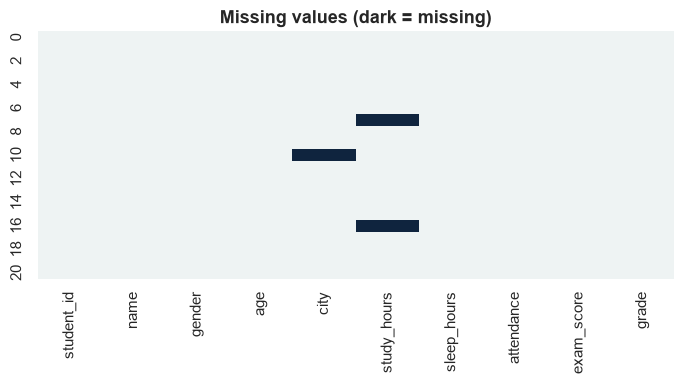

In [72]:
df = load_students()
print("Missing values per column:")
print(df.isnull().sum())
print("\nRows that have a gap:")
print(df[df.isnull().any(axis=1)][["name", "city", "study_hours"]])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df.isnull(), cbar=False, cmap=["#EEF3F3", NAVY], ax=ax)
ax.set_title("Missing values (dark = missing)")
save(fig, "ex04_missing")

**Try it yourself 4:** Print the NAMES of the students whose study_hours is missing.

In [73]:
# Your answer here
# Load student data
df = load_students()

# True where study_hours is missing, False otherwise
missing = df["study_hours"].isnull()

# Keep only those rows, then show just the name column
print(df[missing]["name"])

7      Layla
16    Nasser
Name: name, dtype: str


## Exercise 5
Fill gaps: median for numbers, mode for categories.

In [74]:
df = load_students()
had_gap = df.isnull().any(axis=1)    # rows that have a gap
median_hours = df["study_hours"].median()
top_city = df["city"].mode()[0]
df["study_hours"] = df["study_hours"].fillna(median_hours)
df["city"] = df["city"].fillna(top_city)
print("study_hours gaps filled with median:", median_hours)
print("city gap filled with mode          :", top_city)
print("Missing values left:", df.isnull().sum().sum())
print(df[had_gap][["name", "city", "study_hours"]])

study_hours gaps filled with median: 6.0
city gap filled with mode          : Riyadh
Missing values left: 0
      name    city  study_hours
7    Layla  Riyadh          6.0
10  Hassan  Riyadh          4.0
16  Nasser  Dammam          6.0


**Try it yourself 5:** Fill study_hours with the MEAN instead of the median. Compare.

In [75]:
# Your answer here

# Load fresh data (with gaps)
df = load_students()
had_gap = df["study_hours"].isnull()   # rows where study_hours is missing

# Calculate both values
mean_hours = df["study_hours"].mean()
median_hours = df["study_hours"].median()
print("Mean  :", round(mean_hours, 2))
print("Median:", median_hours)

# Fill the gaps with the mean
df["study_hours"] = df["study_hours"].fillna(mean_hours)

# Show the students that were filled
print(df[had_gap][["name", "study_hours"]])

Mean  : 6.37
Median: 6.0
      name  study_hours
7    Layla     6.368421
16  Nasser     6.368421


## Exercise 6
Find and remove rows that were entered twice.

In [76]:
df = load_students()
print("Rows before       :", len(df))
print("Duplicate rows    :", df.duplicated().sum())
twins = df[df.duplicated(keep=False)]     # show both copies
print(twins[["student_id", "name", "exam_score"]])
df = df.drop_duplicates()
print("Rows after removal:", len(df))

Rows before       : 21
Duplicate rows    : 1
    student_id   name  exam_score
5            6  Noura          76
20           6  Noura          76
Rows after removal: 20


**Try it yourself 6:** Check for duplicates using only the 'name' column.

In [77]:
# Your answer here
# Load student data
df = load_students()

# Count rows where the name already appeared before
print("Duplicate names:", df.duplicated(subset=["name"]).sum())

# Show all rows that share a name (both copies)
same_name = df[df.duplicated(subset=["name"], keep=False)]
print(same_name[["student_id", "name", "exam_score"]])


Duplicate names: 1
    student_id   name  exam_score
5            6  Noura          76
20           6  Noura          76


---
# Part D - Charts for one column

## Exercise 7
Histogram: how the values of one number column are spread.

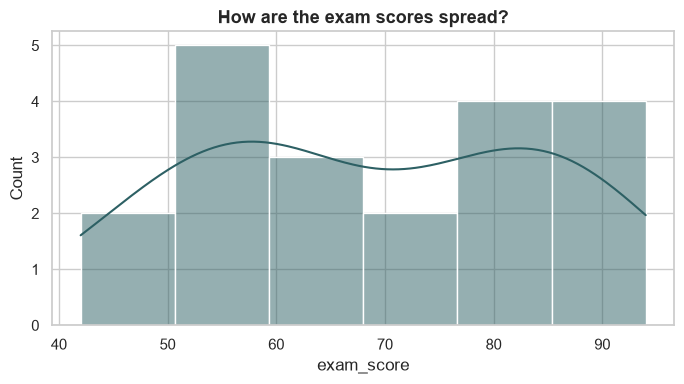

The middle half of the class scored 56.5 to 82.75


In [78]:
df = clean_students()
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["exam_score"], bins=6, kde=True, color=TEAL, ax=ax)
ax.set_title("How are the exam scores spread?")
save(fig, "ex07_histogram")
q1, q3 = df["exam_score"].quantile([0.25, 0.75])
print("The middle half of the class scored", q1, "to", q3)

**Try it yourself 7:** Histogram of attendance with 5 bins. Is it skewed?

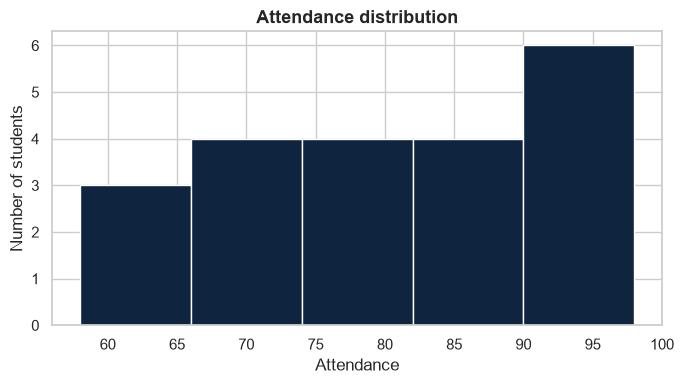

Mean  : 79.8
Median: 80.0
Skew  : -0.19


In [79]:
# Your answer here
# Load student data
df = load_students()

# Draw a histogram of attendance with 5 bins
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["attendance"].dropna(), bins=5, color=NAVY, edgecolor="white")
ax.set_title("Attendance distribution")
ax.set_xlabel("Attendance")
ax.set_ylabel("Number of students")
save(fig, "ex07_attendance_hist")

# Check skew with numbers
print("Mean  :", round(df["attendance"].mean(), 1))
print("Median:", df["attendance"].median())
print("Skew  :", round(df["attendance"].skew(), 2))

## Exercise 8
Box plot: middle 50%, median and outliers at a glance.

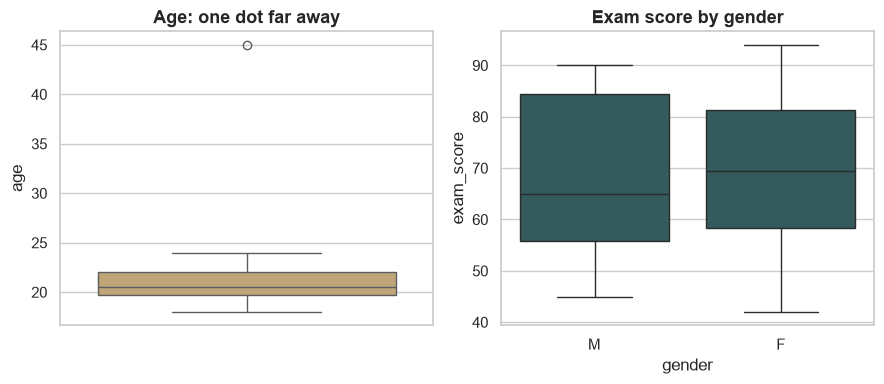

Median exam score by gender:
gender
F    69.5
M    65.0
Name: exam_score, dtype: float64


In [80]:
df = clean_students()
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.boxplot(y=df["age"], color=GOLD, ax=axes[0])
axes[0].set_title("Age: one dot far away")
sns.boxplot(data=df, x="gender", y="exam_score", ax=axes[1])
axes[1].set_title("Exam score by gender")
save(fig, "ex08_boxplot")
print("Median exam score by gender:")
print(df.groupby("gender")["exam_score"].median())

**Try it yourself 8:** Box plot of exam_score for each city.

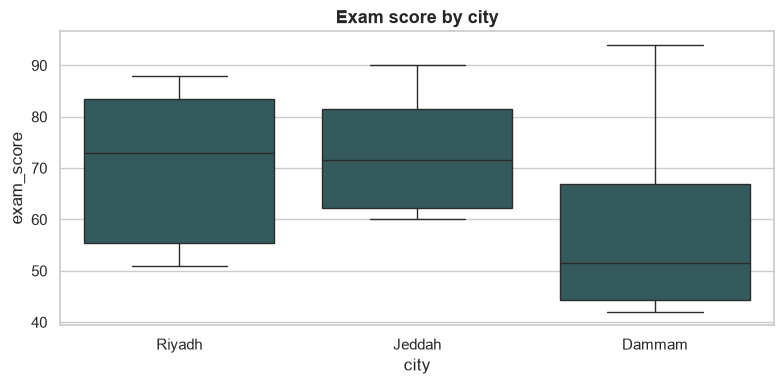

Median exam score by city:
city
Dammam    51.5
Jeddah    71.5
Riyadh    73.0
Name: exam_score, dtype: float64


In [81]:
# Your answer here
# Load cleaned student data
df = clean_students()

# One box of exam scores for each city
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="city", y="exam_score", ax=ax)
ax.set_title("Exam score by city")
save(fig, "ex08_boxplot_city")

# Median exam score for each city
print("Median exam score by city:")
print(df.groupby("city")["exam_score"].median())

## Exercise 9
Bar chart: count of students in each grade.

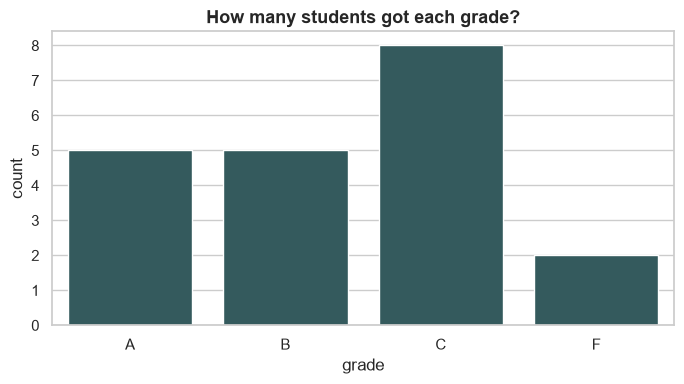

grade
A    5
B    5
C    8
F    2
Name: count, dtype: int64


In [82]:
df = clean_students()
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="grade", order=["A", "B", "C", "F"],
              color=TEAL, ax=ax)
ax.set_title("How many students got each grade?")
save(fig, "ex09_bar_chart")
print(df["grade"].value_counts().reindex(["A", "B", "C", "F"]))

**Try it yourself 9:** Bar chart of how many students of each gender.

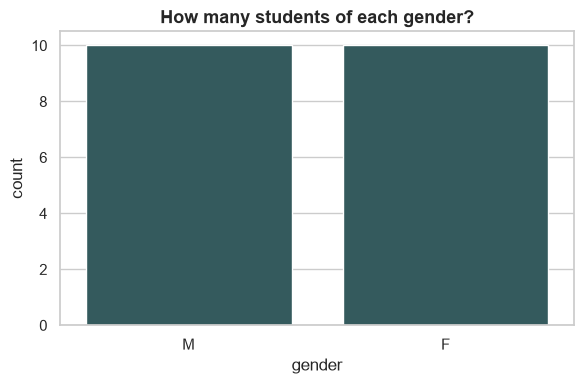

gender
M    10
F    10
Name: count, dtype: int64


In [83]:
# Your answer here

# Load cleaned student data
df = clean_students()

# One bar for each gender, height = number of students
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="gender", color=TEAL, ax=ax)
ax.set_title("How many students of each gender?")
save(fig, "ex09_gender_bar")

# Same counts as numbers
print(df["gender"].value_counts())

## Exercise 10
Pie chart: share of each city (use only for a few categories).

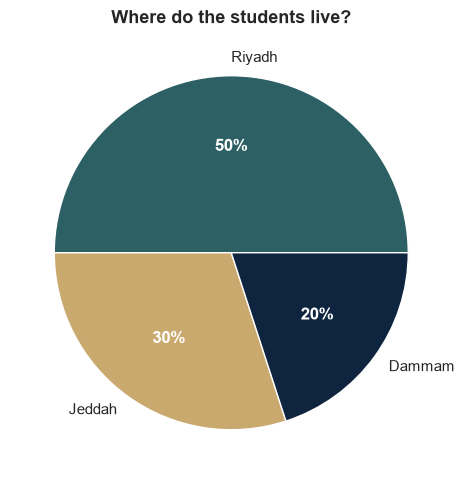

city
Riyadh    50.0
Jeddah    30.0
Dammam    20.0
Name: count, dtype: float64


In [84]:
df = clean_students()
counts = df["city"].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
parts = ax.pie(counts, labels=counts.index, autopct="%1.0f%%",
               colors=[TEAL, GOLD, NAVY])
plt.setp(parts[2], color="white", fontweight="bold")  # % labels
ax.set_title("Where do the students live?")
save(fig, "ex10_pie_chart")
print((counts / counts.sum() * 100).round(0))

**Try it yourself 10:** Pie chart of the grades.

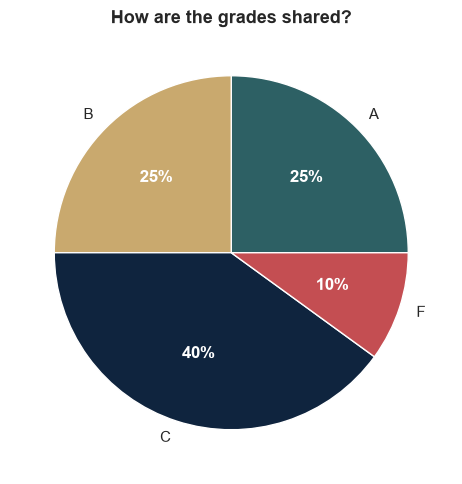

grade
A    25.0
B    25.0
C    40.0
F    10.0
Name: count, dtype: float64


In [85]:
# Your answer here

# Load cleaned student data
df = clean_students()

# Count students in each grade, sorted A, B, C, F
counts = df["grade"].value_counts().sort_index()

# Draw the pie chart with percentages on each slice
fig, ax = plt.subplots(figsize=(5, 5))
parts = ax.pie(counts, labels=counts.index, autopct="%1.0f%%",
               colors=[TEAL, GOLD, NAVY, "#C44E52"])
plt.setp(parts[2], color="white", fontweight="bold")  # % labels
ax.set_title("How are the grades shared?")
save(fig, "ex10_grades_pie")

# Same percentages as numbers
print((counts / counts.sum() * 100).round(0))


---
# Part E - Two or more columns together

## Exercise 11
Scatter plot + correlation: do two number columns move together?

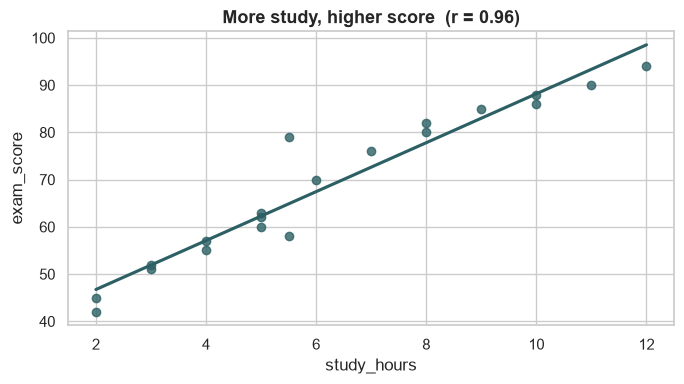

Correlation between study_hours and exam_score: 0.96


In [86]:
df = clean_students()
r = df["study_hours"].corr(df["exam_score"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(data=df, x="study_hours", y="exam_score", ci=None,
            color=TEAL, ax=ax)
ax.set_title(f"More study, higher score  (r = {r:.2f})")
save(fig, "ex11_scatter")
print("Correlation between study_hours and exam_score:", round(r, 2))

**Try it yourself 11:** Scatter plot of attendance vs exam_score. What is r?

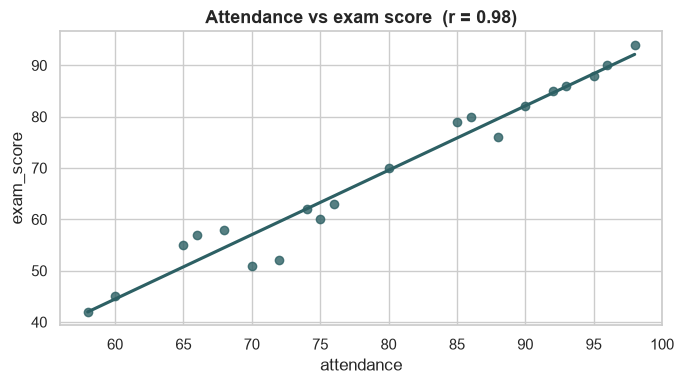

Correlation between attendance and exam_score: 0.98


In [87]:
# Your answer here

# Load cleaned student data
df = clean_students()

# Correlation between attendance and exam score
r = df["attendance"].corr(df["exam_score"])

# Scatter plot with a trend line
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(data=df, x="attendance", y="exam_score", ci=None,
            color=TEAL, ax=ax)
ax.set_title(f"Attendance vs exam score  (r = {r:.2f})")
save(fig, "ex11_attendance_scatter")

# Print r
print("Correlation between attendance and exam_score:", round(r, 2))


## Exercise 12
Line chart: how a value changes over time.

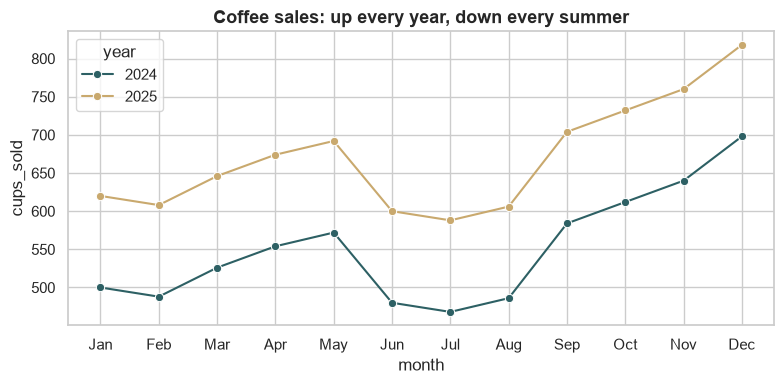

Total cups sold per year:
year
2024    6608
2025    8048
Name: cups_sold, dtype: int64


In [88]:
sales = load_sales()
sales["year"] = sales["year"].astype(str)
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=sales, x="month", y="cups_sold", hue="year",
             marker="o", sort=False, ax=ax)
ax.set_title("Coffee sales: up every year, down every summer")
save(fig, "ex12_line_chart")
print("Total cups sold per year:")
print(sales.groupby("year")["cups_sold"].sum())

**Try it yourself 12:** Which month had the lowest sales each year? How much did sales grow?

In [89]:
# Your answer here
# Load coffee sales data
sales = load_sales()
sales["year"] = sales["year"].astype(str)

# Q1: the month with the lowest sales in each year
lowest_rows = sales.groupby("year")["cups_sold"].idxmin()
print("Lowest month each year:")
print(sales.loc[lowest_rows, ["year", "month", "cups_sold"]])

# Q2: total cups sold per year
totals = sales.groupby("year")["cups_sold"].sum()
print("\nTotal cups sold per year:")
print(totals)

# Growth from one year to the next (in %)
print("\nGrowth from previous year (%):")
print((totals.pct_change() * 100).round(1))

# Growth from the first year to the last year (in %)
growth = (totals.iloc[-1] - totals.iloc[0]) / totals.iloc[0] * 100
print("\nTotal growth, first to last year:", round(growth, 1), "%")

Lowest month each year:
    year month  cups_sold
6   2024   Jul        468
18  2025   Jul        588

Total cups sold per year:
year
2024    6608
2025    8048
Name: cups_sold, dtype: int64

Growth from previous year (%):
year
2024     NaN
2025    21.8
Name: cups_sold, dtype: float64

Total growth, first to last year: 21.8 %


## Exercise 13
Correlation heatmap: every pair of number columns in one picture.

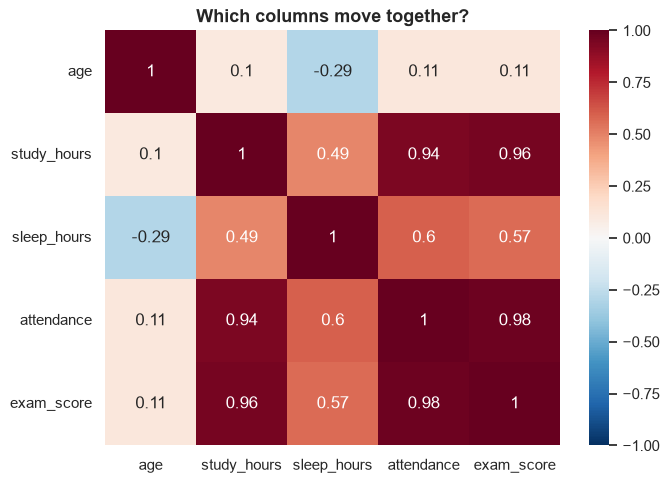

Correlation with exam_score:
exam_score     1.00
attendance     0.98
study_hours    0.96
sleep_hours    0.57
age            0.11
Name: exam_score, dtype: float64


In [90]:
df = clean_students()
cols = ["age", "study_hours", "sleep_hours",
        "attendance", "exam_score"]
corr = df[cols].corr().round(2)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Which columns move together?")
save(fig, "ex13_heatmap")
print("Correlation with exam_score:")
print(corr["exam_score"].sort_values(ascending=False))

**Try it yourself 13:** Which column is the most related to exam_score (not itself)?

In [91]:
# Your answer here
# Load cleaned student data
df = clean_students()
cols = ["age", "study_hours", "sleep_hours",
        "attendance", "exam_score"]

# Correlation of every column with exam_score, without exam_score itself
corr = df[cols].corr().round(2)
with_score = corr["exam_score"].drop("exam_score")
print("Correlation with exam_score:")
print(with_score.sort_values(ascending=False))

# Strongest relation (positive or negative), using absolute value
best = with_score.abs().idxmax()
print("\nMost related to exam_score:", best, "(r =", with_score[best], ")")

Correlation with exam_score:
attendance     0.98
study_hours    0.96
sleep_hours    0.57
age            0.11
Name: exam_score, dtype: float64

Most related to exam_score: attendance (r = 0.98 )


## Exercise 14
Crosstab: count two categories together.

grade   A  B  C  F
gender            
F       2  3  4  1
M       3  2  4  1


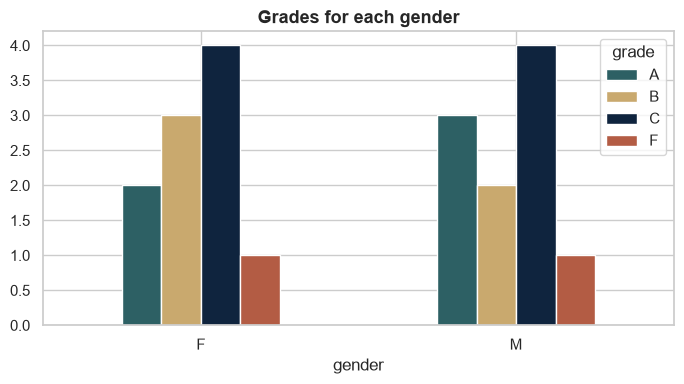

In [92]:
df = clean_students()
table = pd.crosstab(df["gender"], df["grade"])
print(table)
fig, ax = plt.subplots(figsize=(7, 4))
table.plot.bar(ax=ax, rot=0, color=[TEAL, GOLD, NAVY, "#B35C44"])
ax.set_title("Grades for each gender")
save(fig, "ex14_crosstab")

**Try it yourself 14:** Crosstab of city and grade, shown as row percentages.

Counts:
grade   A  B  C  F
city              
Dammam  1  0  1  2
Jeddah  1  2  3  0
Riyadh  3  3  4  0

Row percentages (%):
grade      A     B     C     F
city                          
Dammam  25.0   0.0  25.0  50.0
Jeddah  16.7  33.3  50.0   0.0
Riyadh  30.0  30.0  40.0   0.0


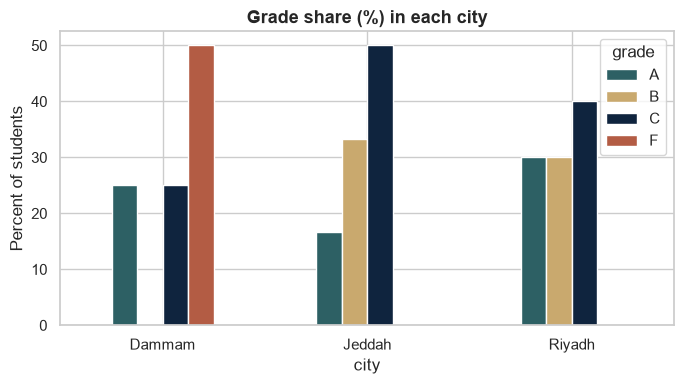

In [93]:
# Your answer here

# Load cleaned student data
df = clean_students()

# Count students for each city + grade pair
counts = pd.crosstab(df["city"], df["grade"])
print("Counts:")
print(counts)

# Row percentages: each city's row adds up to 100%
table = (pd.crosstab(df["city"], df["grade"], normalize="index") * 100).round(1)
print("\nRow percentages (%):")
print(table)

# Bar chart of the percentages
fig, ax = plt.subplots(figsize=(7, 4))
table.plot.bar(ax=ax, rot=0, color=[TEAL, GOLD, NAVY, "#B35C44"])
ax.set_title("Grade share (%) in each city")
ax.set_ylabel("Percent of students")
save(fig, "ex14_city_grade")


## Exercise 15
groupby: compare the same number across groups.

        count  mean  min  max
city                         
Dammam      4  59.8   42   94
Jeddah      6  72.8   60   90
Riyadh     10  69.9   51   88


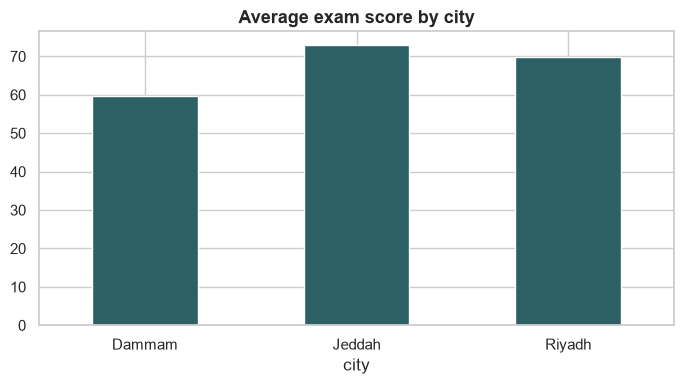

In [94]:
df = clean_students()
summary = df.groupby("city")["exam_score"].agg(
    ["count", "mean", "min", "max"])
print(summary.round(1))
fig, ax = plt.subplots(figsize=(7, 4))
summary["mean"].plot.bar(ax=ax, rot=0, color=TEAL)
ax.set_title("Average exam score by city")
save(fig, "ex15_group_compare")

**Try it yourself 15:** Average study_hours and exam_score for each gender.

        study_hours  exam_score
gender                         
F               6.0        69.2
M               6.4        68.3


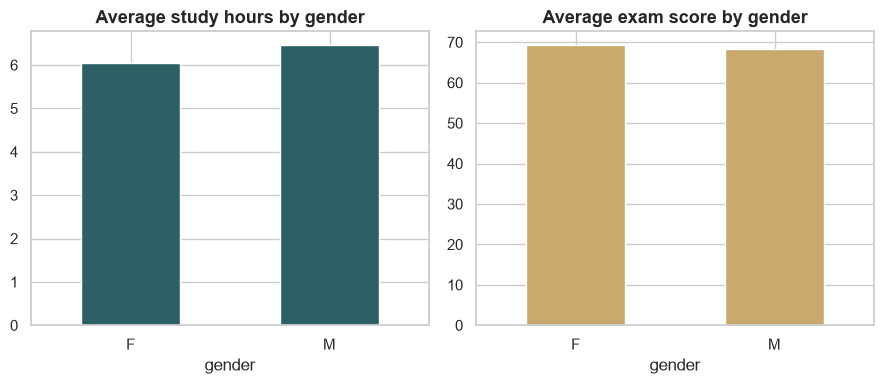

In [95]:
# Your answer here

# Load cleaned student data
df = clean_students()

# Average study hours and exam score for each gender
summary = df.groupby("gender")[["study_hours", "exam_score"]].mean()
print(summary.round(1))

# Two charts side by side (the numbers have different scales)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
summary["study_hours"].plot.bar(ax=axes[0], rot=0, color=TEAL)
axes[0].set_title("Average study hours by gender")
summary["exam_score"].plot.bar(ax=axes[1], rot=0, color=GOLD)
axes[1].set_title("Average exam score by gender")
save(fig, "ex15_gender_compare")

---
# Part F - Prepare the data for a model

## Exercise 16
IQR rule: find values that are far from the rest, then cap them.

Q1=19.75 Q3=22.0 IQR=2.25 -> normal: 16.375 to 25.375
   name  age
9  Reem   45
Max age before: 45  after: 25.375


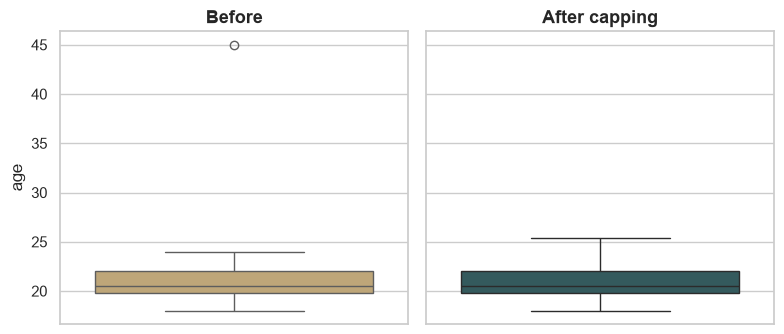

In [96]:
df = clean_students()
q1, q3 = df["age"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1={q1} Q3={q3} IQR={iqr} -> normal: {low} to {high}")
outliers = (df["age"] < low) | (df["age"] > high)
print(df[outliers][["name", "age"]])
df["age_capped"] = df["age"].clip(low, high)   # cap = clip
print("Max age before:", df["age"].max(),
      " after:", df["age_capped"].max())
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
sns.boxplot(y=df["age"], color=GOLD, ax=axes[0])
sns.boxplot(y=df["age_capped"], color=TEAL, ax=axes[1])
axes[0].set_title("Before")
axes[1].set_title("After capping")
save(fig, "ex16_outliers")

**Try it yourself 16:** Use the IQR rule on exam_score. Are there outliers?

Q1=56.5 Q3=82.75 IQR=26.25 -> normal: 17.125 to 122.125
Number of outliers: 0
Empty DataFrame
Columns: [name, exam_score]
Index: []
Min before: 42  after: 42
Max before: 94  after: 94


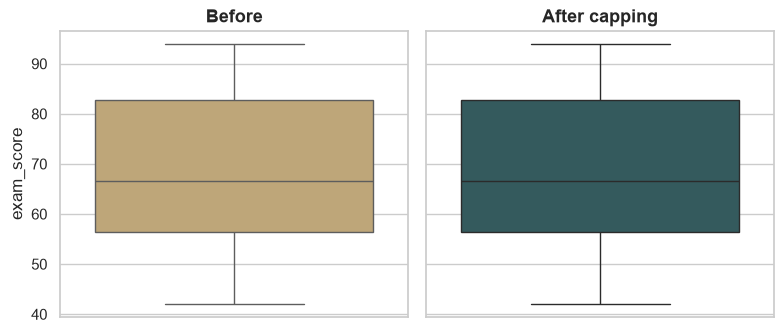

In [97]:
# Your answer here

# Load cleaned student data
df = clean_students()

# Q1, Q3 and IQR for exam_score
q1, q3 = df["exam_score"].quantile([0.25, 0.75])
iqr = q3 - q1

# Normal range: anything outside is an outlier
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1={q1} Q3={q3} IQR={iqr} -> normal: {low} to {high}")

# Find the outliers
outliers = (df["exam_score"] < low) | (df["exam_score"] > high)
print("Number of outliers:", outliers.sum())
print(df[outliers][["name", "exam_score"]])

# Cap the outliers to the normal range
df["score_capped"] = df["exam_score"].clip(low, high)
print("Min before:", df["exam_score"].min(), " after:", df["score_capped"].min())
print("Max before:", df["exam_score"].max(), " after:", df["score_capped"].max())

# Box plots before and after
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
sns.boxplot(y=df["exam_score"], color=GOLD, ax=axes[0])
sns.boxplot(y=df["score_capped"], color=TEAL, ax=axes[1])
axes[0].set_title("Before")
axes[1].set_title("After capping")
save(fig, "ex16_score_outliers")

## Exercise 17
Put columns on the same scale: Min-Max and Z-score.

In [98]:
df = clean_students()
x = df["study_hours"]
df["minmax"] = (x - x.min()) / (x.max() - x.min())
df["zscore"] = (x - x.mean()) / x.std()
cols = ["name", "study_hours", "minmax", "zscore"]
print(df[cols].head(5).round(2))
print("\nMin-Max goes from", df["minmax"].min(),
      "to", df["minmax"].max())
print("Z-score mean  :", round(df["zscore"].mean(), 2),
      " std:", round(df["zscore"].std(), 2))

     name  study_hours  minmax  zscore
0   Ahmed         10.0     0.8    1.25
1    Sara          8.0     0.6    0.58
2    Omar          3.0     0.1   -1.08
3  Fatima         12.0     1.0    1.92
4  Khalid          5.0     0.3   -0.42

Min-Max goes from 0.0 to 1.0
Z-score mean  : -0.0  std: 1.0


**Try it yourself 17:** Min-Max scale attendance. Check that min = 0 and max = 1.

In [99]:
# Your answer here
# Load cleaned student data
df = clean_students()
x = df["study_hours"]

# Min-Max: squeeze values into 0 to 1
df["minmax"] = (x - x.min()) / (x.max() - x.min())

# Z-score: distance from the mean, in standard deviations
df["zscore"] = (x - x.mean()) / x.std()

# Show the first 5 students: original vs scaled
cols = ["name", "study_hours", "minmax", "zscore"]
print(df[cols].head(5).round(2))

# Check: Min-Max should be 0 to 1
print("\nMin-Max goes from", df["minmax"].min(),
      "to", df["minmax"].max())

# Check: Z-score should have mean 0 and std 1
print("Z-score mean  :", round(df["zscore"].mean(), 2),
      " std:", round(df["zscore"].std(), 2))

     name  study_hours  minmax  zscore
0   Ahmed         10.0     0.8    1.25
1    Sara          8.0     0.6    0.58
2    Omar          3.0     0.1   -1.08
3  Fatima         12.0     1.0    1.92
4  Khalid          5.0     0.3   -0.42

Min-Max goes from 0.0 to 1.0
Z-score mean  : -0.0  std: 1.0


## Exercise 18
Turn text categories into numbers.

In [100]:
df = clean_students()[["name", "city", "grade"]].head(5)
grade_order = {"F": 0, "C": 1, "B": 2, "A": 3}
df["grade_num"] = df["grade"].map(grade_order)   # ordinal
df = pd.get_dummies(df, columns=["city"], dtype=int)  # one-hot
print(df)

     name grade  grade_num  city_Dammam  city_Jeddah  city_Riyadh
0   Ahmed     A          3            0            0            1
1    Sara     B          2            0            1            0
2    Omar     C          1            0            0            1
3  Fatima     A          3            1            0            0
4  Khalid     C          1            0            1            0


**Try it yourself 18:** Encode gender as numbers (two ways).

In [101]:
# Your answer here
# Take 3 columns and the first 5 students
df = clean_students()[["name", "city", "grade"]].head(5)

# Ordinal: give each grade a number that keeps the order
grade_order = {"F": 0, "C": 1, "B": 2, "A": 3}
df["grade_num"] = df["grade"].map(grade_order)

# One-hot: one 0/1 column for each city
df = pd.get_dummies(df, columns=["city"], dtype=int)

print(df)

     name grade  grade_num  city_Dammam  city_Jeddah  city_Riyadh
0   Ahmed     A          3            0            0            1
1    Sara     B          2            0            1            0
2    Omar     C          1            0            0            1
3  Fatima     A          3            1            0            0
4  Khalid     C          1            0            1            0


## Exercise 19
Create new, more useful columns from the ones we have.

In [102]:
df = clean_students()
df["passed"] = df["exam_score"] >= 50
df["study_level"] = pd.cut(df["study_hours"], bins=[0, 4, 8, 12],
                           labels=["Low", "Medium", "High"])
print(df[["name", "study_hours", "study_level", "passed"]].head(6))
print("\nAverage exam score per study level:")
by_level = df.groupby("study_level", observed=True)
print(by_level["exam_score"].mean().round(1))
print("\nPass rate:", round(df["passed"].mean() * 100), "%")

     name  study_hours study_level  passed
0   Ahmed         10.0        High    True
1    Sara          8.0      Medium    True
2    Omar          3.0         Low    True
3  Fatima         12.0        High    True
4  Khalid          5.0      Medium    True
5   Noura          7.0      Medium    True

Average exam score per study level:
study_level
Low       50.3
Medium    70.0
High      88.6
Name: exam_score, dtype: float64

Pass rate: 90 %


**Try it yourself 19:** Add 'attendance_level' (Low < 70, Medium 70-89, High >= 90).

In [103]:
# Your answer here

# Load cleaned student data
df = clean_students()

# Turn attendance numbers into 3 levels
df["attendance_level"] = pd.cut(df["attendance"],
                                bins=[0, 70, 90, float("inf")],
                                labels=["Low", "Medium", "High"],
                                right=False)

# Check a few students
print(df[["name", "attendance", "attendance_level"]].head(6))

# How many students in each level
print("\nStudents per attendance level:")
print(df["attendance_level"].value_counts().sort_index())

# Average exam score for each level
print("\nAverage exam score per attendance level:")
by_level = df.groupby("attendance_level", observed=True)
print(by_level["exam_score"].mean().round(1))

     name  attendance attendance_level
0   Ahmed          95             High
1    Sara          90             High
2    Omar          70           Medium
3  Fatima          98             High
4  Khalid          75           Medium
5   Noura          88           Medium

Students per attendance level:
attendance_level
Low       5
Medium    9
High      6
Name: count, dtype: int64

Average exam score per attendance level:
attendance_level
Low       51.4
Medium    65.9
High      87.5
Name: exam_score, dtype: float64


---
# Part G - Text data

## Exercise 20
Explore text: length of each review and the most common words.

Average words per review:
sentiment
negative    6.8
positive    7.0
Name: word_count, dtype: float64

Top words:
 text
app        4
fast       3
easy       3
great      3
support    3
use        2
update     2
slow       2
Name: count, dtype: int64


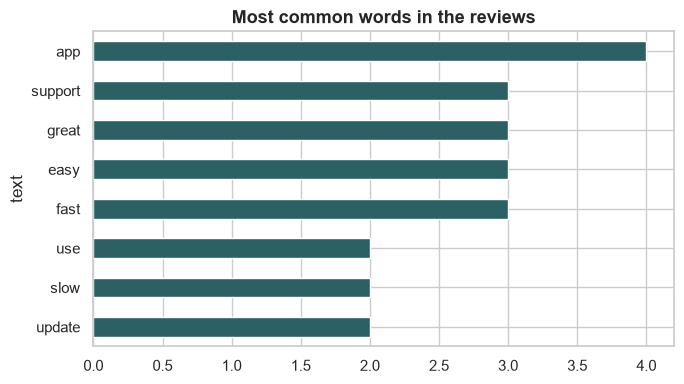

In [104]:
reviews = load_reviews()
reviews["word_count"] = reviews["text"].str.split().str.len()
print("Average words per review:")
print(reviews.groupby("sentiment")["word_count"].mean())
words = reviews["text"].str.lower().str.split().explode()
words = words[~words.isin(STOP_WORDS)]
top = words.value_counts().head(8)
print("\nTop words:\n", top)
fig, ax = plt.subplots(figsize=(7, 4))
top.sort_values().plot.barh(ax=ax, color=TEAL)
ax.set_title("Most common words in the reviews")
save(fig, "ex20_text_eda")

**Try it yourself 20:** Top 3 words in the NEGATIVE reviews.

Average words per review:
sentiment
negative    6.8
positive    7.0
Name: word_count, dtype: float64

Top words:
 text
app        4
fast       3
easy       3
great      3
support    3
use        2
update     2
slow       2
Name: count, dtype: int64


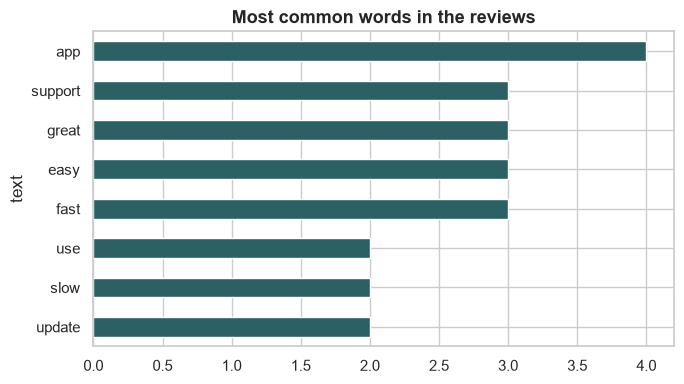

In [105]:
# Your answer here

# Load the reviews data
reviews = load_reviews()

# Count the words in each review
reviews["word_count"] = reviews["text"].str.split().str.len()

# Average review length for positive vs negative
print("Average words per review:")
print(reviews.groupby("sentiment")["word_count"].mean())

# Put every word from every review in one long list (lowercase)
words = reviews["text"].str.lower().str.split().explode()

# Remove common filler words (the, is, and...)
words = words[~words.isin(STOP_WORDS)]

# The 8 most frequent words
top = words.value_counts().head(8)
print("\nTop words:\n", top)

# Horizontal bar chart of the top words
fig, ax = plt.subplots(figsize=(7, 4))
top.sort_values().plot.barh(ax=ax, color=TEAL)
ax.set_title("Most common words in the reviews")
save(fig, "ex20_text_eda")